## Clase 3 - Correlación entre variables

### Correlación: qué mide y qué no

La correlación resume, con un solo número entre -1 y 1, qué tan asociadas están dos variables. Es una herramienta central en la exploración de datos, pero **el número que da depende del método que uses** — y elegir mal puede hacerte creer que dos variables no están relacionadas cuando en realidad sí lo están (o al revés).

Antes de ver el código: existen tres tipos de relación entre dos variables que nos interesa distinguir:
- **Lineal**: `y` crece (o decrece) a un ritmo constante junto con `x`.
- **Monótona no lineal**: `y` siempre crece o siempre decrece con `x`, pero no a un ritmo constante.
- **No monótona**: `y` a veces crece y a veces decrece con `x` (por ejemplo, una parábola).

Vamos a construir un ejemplo de cada una y comparar qué detecta cada método de correlación.

### Librerías de esta notebook

Además de `pandas`, `numpy`, `seaborn` y `matplotlib` (que ya usamos en la notebook anterior), importamos algunas herramientas de `scikit-learn` y `category_encoders` que **no se usan en esta notebook** — quedan preparadas para cuando veamos selección de variables y codificación de categóricas más adelante. Si te llama la atención ver imports "sin usar", es por eso.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, StandardScaler
from category_encoders import BinaryEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split


#### 1) Correlación: para tener en cuenta

In [2]:
np.random.seed(42)
df = pd.DataFrame(range(-100,101,1), columns=['x'])
df['y1'] = 10 * df['x'] + 2
df['y2'] = 1/np.exp(df['x'])
df['y3'] = np.square(df['x'])

df.head()

,x,y1,y2,y3
0,-100,-998,2.688117e+43,10000
1,-99,-988,9.889030e+42,9801
2,-98,-978,3.637971e+42,9604
3,-97,-968,1.338335e+42,9409
4,-96,-958,4.923458e+41,9216


> 💡 **En vivo:** antes de correr la celda de abajo, miremos las 3 formas y arriesguemos: ¿en cuál esperamos una correlación de Pearson alta? ¿en cuál baja?

Text(0, 0.5, 'y3')

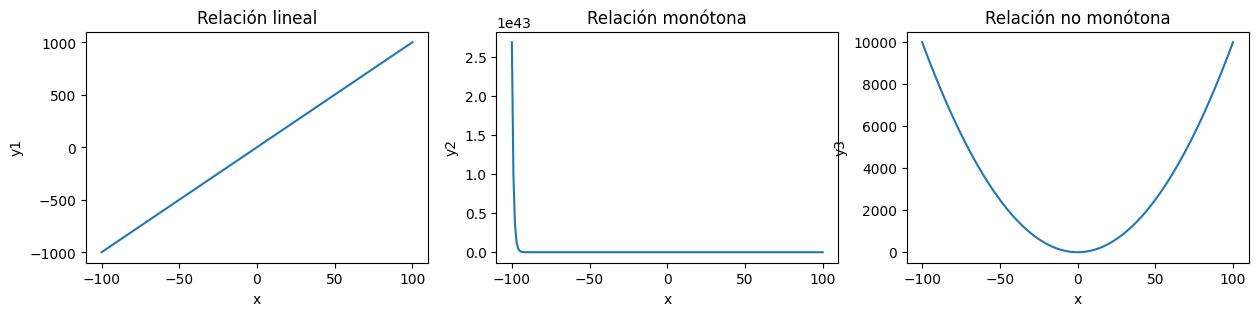

In [3]:
plt.figure(figsize=(15,3))

plt.subplot(1,3,1)
plt.plot(df['x'],df['y1'],'-')
plt.title('Relación lineal')
plt.xlabel('x')
plt.ylabel('y1')

plt.subplot(1,3,2)
plt.plot(df['x'],df['y2'],'-')
plt.title('Relación monótona')
plt.xlabel('x')
plt.ylabel('y2')

plt.subplot(1,3,3)
plt.plot(df['x'],df['y3'],'-')
plt.title('Relación no monótona')
plt.xlabel('x')
plt.ylabel('y3')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       201 non-null    int64  
 1   y1      201 non-null    int64  
 2   y2      201 non-null    float64
 3   y3      201 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 6.4 KB


#### 2) Comparando métodos de correlación

- **Pearson** (el más usado por defecto) solo detecta relaciones **lineales**.
- **Spearman** y **Kendall** trabajan sobre el orden (ranking) de los valores, no sobre su magnitud: detectan cualquier relación **monótona**, sea lineal o no.
- Ninguno de los tres detecta relaciones **no monótonas** (como una parábola), porque en esos casos "sube y después baja": en promedio, no hay una tendencia única que capturar.

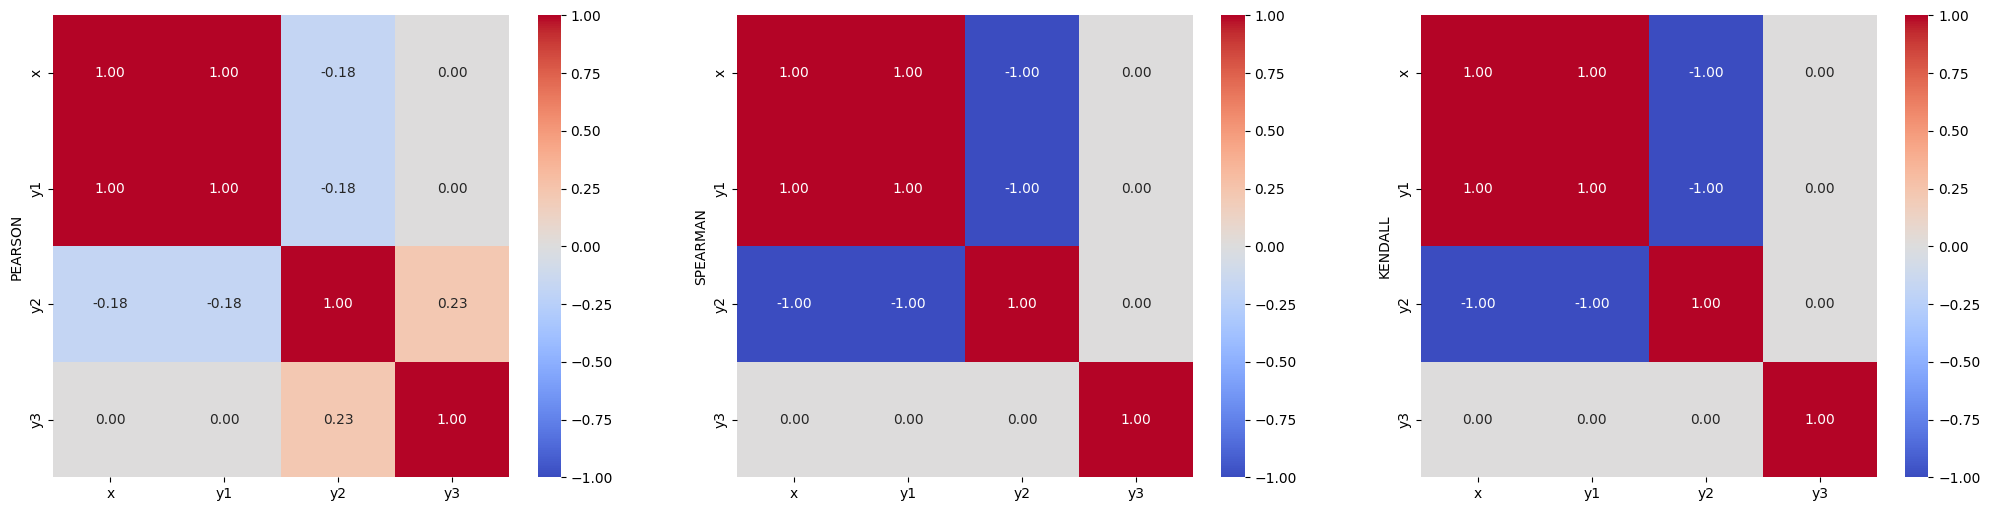

In [5]:
plt.figure(figsize=(25,6))

plt.subplot(1, 3, 1)
sns.heatmap(
    df.corr(numeric_only=False), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
plt.ylabel('PEARSON')

plt.subplot(1, 3, 2)
sns.heatmap(
    df.corr(method='spearman', numeric_only=False),
    annot=True, 
    fmt=".2f",  
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,)
plt.ylabel('SPEARMAN')

plt.subplot(1, 3, 3)
sns.heatmap(
    df.corr(method='kendall', numeric_only=False), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",
    center=0, 
    vmin=-1, 
    vmax=1,)
plt.ylabel('KENDALL')

plt.show()


**Conclusiones:**
* Pearson no detecta las relaciones con `y2` (monótona no lineal) ni con `y3` (no monótona, no lineal).
* Kendall y Spearman no detectan la relación con `y3` (no monótona, no lineal), pero sí con `y2`.
* Ninguno detecta la relación cuadrática entre `x` e `y3` (no monótona).
* Con Pandas, en ningún caso se está evaluando la significancia estadística (p-valor) — un coeficiente de correlación por sí solo no te dice si la relación es estadísticamente significativa.

## Resumen

- La correlación no es un solo concepto: **Pearson** mide relación lineal, **Spearman**/**Kendall** miden relación monótona (basados en el orden de los datos, no en su valor).
- Un coeficiente de correlación bajo **no significa que no haya relación** — puede haber una relación fuerte pero no monótona (como `y3`), invisible a los tres métodos.
- Antes de descartar una variable por "baja correlación", conviene graficarla (como hicimos arriba) para no perderte relaciones no lineales.